In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def run_classification_audition(X, y, test_size=0.2, random_state=42):
    """
    ヒント(X)と答え(y)を渡すだけで、標準化前処理から
    「ロジスティック回帰」「決定木」「ランダムフォレスト」を一括評価する関数
    """
    # 1. データの分割
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # 2. パイプラインの定義（すべてscikit-learnの、説明しやすいモデルたち）
    pipelines = {
        'LogisticRegression': Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(random_state=random_state))
        ]),
        'DecisionTree': Pipeline([
            ('scaler', StandardScaler()),
            ('dt', DecisionTreeClassifier(max_depth=3, random_state=random_state)) # 見やすさ重視で深さを3に制限
        ]),
        'RandomForest': Pipeline([
            ('scaler', StandardScaler()),
            ('rf', RandomForestClassifier(random_state=random_state))
        ])
    }
    
    print("--- ⚙️ scikit-learn 分類一括オーディション開始 ---")
    results = {}
    for name, pipe in pipelines.items():
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_val)
        
        # 今回は2択の「正解率（Accuracy）」で競います
        score = accuracy_score(y_val, y_pred)
        print(f"{name} の正解率: {score:.5f}")
        results[name] = pipe
        
    return results

In [14]:
pd.set_option('display.max_columns', None) # データフレームの全列を表示する設定
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [16]:
X = df.drop(columns=['customerID', 'Churn']) # ヒント（説明変数）
y = df['Churn'].map({'Yes': 1, 'No': 0}) # 答え（目的変数）を0/1に変換
# こちらの方が実務でよく見る「文字列の列名リスト」を自動で作る技
obj_cols = X.select_dtypes(include=['object']).columns
X[obj_cols] = X[obj_cols].astype('category')
# drop_first=True をつけるのが、実務的なスマートな書き方
X = pd.get_dummies(X, drop_first=True)
results = run_classification_audition(X, y)

--- ⚙️ scikit-learn 分類一括オーディション開始 ---
LogisticRegression の正解率: 0.78424
DecisionTree の正解率: 0.80199
RandomForest の正解率: 0.79986



---  LogisticRegression の重要度を調査 ---


C:\Users\user\AppData\Local\Temp\ipykernel_17100\4287165846.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp.head(10), palette='magma')


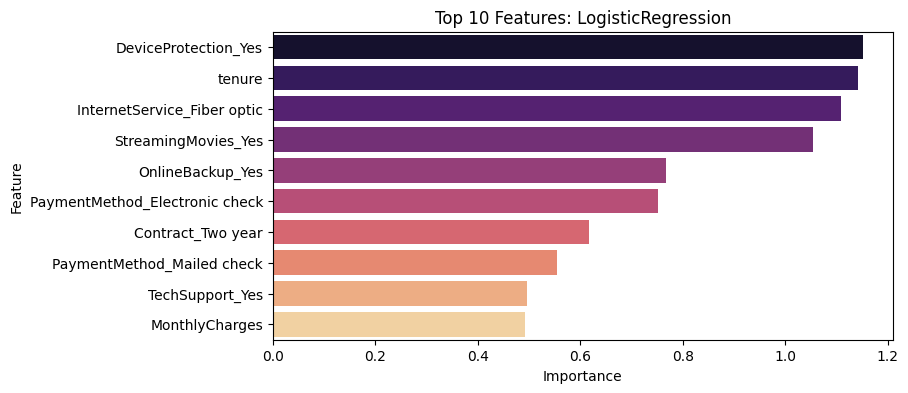


---  DecisionTree の重要度を調査 ---


C:\Users\user\AppData\Local\Temp\ipykernel_17100\4287165846.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp.head(10), palette='magma')


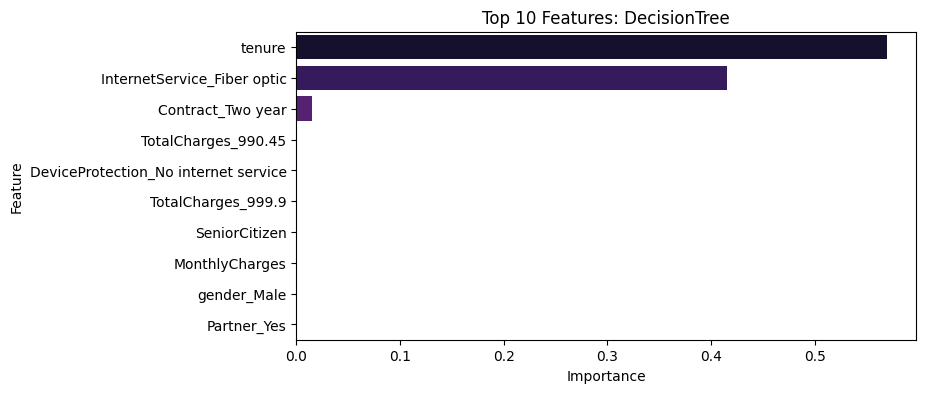


---  RandomForest の重要度を調査 ---


C:\Users\user\AppData\Local\Temp\ipykernel_17100\4287165846.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp.head(10), palette='magma')


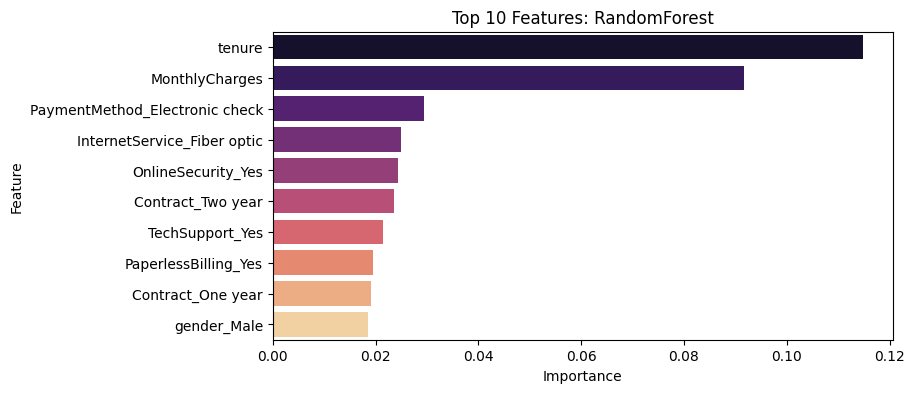

In [17]:
# 1. 3つのモデルの結果が入った箱（results）から、それぞれのAIを取り出す
for name, pipe in results.items():
    print(f"\n---  {name} の重要度を調査 ---")
    
    # 決定木やランダムフォレストは 'dt' や 'rf' という名前でパイプラインに入れています
    # モデルの本体を取り出すための辞書を用意
    model_name = list(pipe.named_steps.keys())[1] # パイプラインの2番目（[0]=scaler, [1]=model）
    model = pipe.named_steps[model_name]
    
    # 【ロジスティック回帰の場合】（係数を取得）
    if name == 'LogisticRegression':
        importances = model.coef_[0]
        
    # 【決定木・ランダムフォレストの場合】（重要度を取得）
    else:
        importances = model.feature_importances_
        
    # 表にまとめてグラフ化
    df_imp = pd.DataFrame({'Feature': X.columns, 'Importance': abs(importances)}).sort_values(by='Importance', ascending=False)
    
    # グラフ表示
    plt.figure(figsize=(8, 4))
    sns.barplot(x='Importance', y='Feature', data=df_imp.head(10), palette='magma')
    plt.title(f'Top 10 Features: {name}')
    plt.show()